In [1]:
%matplotlib widget
import pybt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()


In [2]:
plt.close('all')

In [3]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

In [4]:
p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


## Defining functions and variables

In [5]:
class SeptumInteraction:
    def __init__(self, blade_position: float = 68e-3, thickness:float = 0.3e-3, kick:float = 1e-3) -> None:
        self.blade_position = blade_position
        self.thickness = thickness
        self.kick = kick
        pass

    def interact(self, particles: xp.Particles) -> t.Optional[t.Dict]:
        n_part = particles._num_active_particles

        # lose the particles on the blade
        particles.state[:n_part] = np.where((particles.x[:n_part]>self.blade_position) & (particles.x[:n_part]<(self.blade_position+self.thickness)) & (particles.state[:n_part]==1), -1, 1)

        # kick the particles beyond the blade
        if self.kick != 0:
            particles.px[:n_part] +=  np.where((particles.x[:n_part] > (self.blade_position+self.thickness)) & (particles.state[:n_part]==1), 1, 0) * self.kick

        return None


In [6]:
# install the 5 zs
def install_septa(line, install_zs=True, septum_aperture_size=68e-3):
    septa_names_with_apertures = []

    if install_zs:
        septum_names = ["zs.21633", "zs.21639", "zs.21655", "zs.21671", "zs.21676"]
        
        for septum_name in septum_names:
            zs = xt.BeamInteraction(
                length=0.0,
                interaction_process=SeptumInteraction(
                    blade_position=septum_aperture_size, thickness=0.3e-3, kick=0.440e-3 / 5
                ),
            )
            line.insert_element(septum_name + ".sep", zs, index=septum_name)
            septa_names_with_apertures.append(septum_name + ".sep")

        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=0
            ),
        )
        line.insert_element("tpst.21760_entry" + ".sep", zs, index="tpst.21760_entry")
        septa_names_with_apertures.append("tpst.21760_entry" + ".sep")


    for mst in ["mst.21774", "mst.21779", "mst.21794"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=5.2e-3, kick=1.69520713e-3 / 3
            ),
        )
        line.insert_element(mst + ".sep", zs, index=mst)
        septa_names_with_apertures.append(mst + ".sep")

    for mse in ["mse.21832", "mse.21837", "mse.21852", "mse.21857", "mse.21872"]:
        zs = xt.BeamInteraction(
            length=0.0,
            interaction_process=SeptumInteraction(
                blade_position=40e-3, thickness=20e-3, kick=9.74519477e-3 / 5
            ),
        )
        line.insert_element(mse + ".sep", zs, index=mse)
        septa_names_with_apertures.append(mse + ".sep")

    septum = xt.LimitRect(min_x=-1.0, max_x=septum_aperture_size, min_y=-1.0, max_y=1.0)


    line.insert_element(
        name="tt20.extraction",
        element=xt.LimitRect(min_x=-1.0, max_x=70e-3, min_y=-1.0, max_y=1.0),
        index="ap.do.mse21872",
    )
    return septa_names_with_apertures


In [7]:
def draw_synoptic(ax, line, line_df):
    
    compound_names = line_df["name"].unique()
    for compound_name in compound_names:
        compound_df = line_df[line_df["name"] == compound_name]
        if compound_df["element_type"].isin(["Quadrupole"]).any():
            k1 = (
                compound_df[compound_df["element_type"] == "Quadrupole"]["element"]
                .squeeze()
                .k1
            )
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, 0), s2 - s1, np.sign(k1), facecolor="k", edgecolor="k"
                )
            )
        elif compound_df["element_type"].isin(["Sextupole", 'Bend', 'Multipole']).any():
            s1, s2 = compound_df["s"].min(), compound_df["s"].max()
            _ = ax.add_patch(
                mpl.patches.Rectangle(
                    (s1, -1), s2 - s1, 2, facecolor="k", edgecolor="k"
                )
            )

def plot_twiss(fig, twiss, line):

    gs = mpl.gridspec.GridSpec(3, 1, height_ratios=[1, 4, 4])
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)     #UNUSED, IMPLEMENT TO HAVE THE VISUAL REPRESENTATION OF THE ENVELOPE THOUGH THE LATTICE

    plt.setp(ax2.get_xticklabels(), visible=False)

    # top plot is synoptic
    ax1.axis('off')
    ax1.set_ylim(-1.2, 1)
    ax1.plot([0, twiss['s'].max()], [0, 0], 'k-')


    #2nd plot is beta functions
    ax2.set_ylabel(r'Twiss (m)')
    ax2.plot(twiss['s'], twiss['betx'], 'r-', label=r'$\beta_x$')
    ax2.plot(twiss['s'], twiss['bety'], 'b-', label=r'$\beta_y$')
    ax2.plot(twiss['s'], twiss['dx']*10, 'g-', label=r'$D_x x10$')
    ax2.set_xlim(twiss['s'][0], twiss['s'][-1])
    ax2.legend(loc='upper right')

    line_df = line.to_pandas()
    line_df = line_df[(line_df['s'] >= twiss.s[0]) & (line_df['s'] <= twiss.s[-1])]

    draw_synoptic(ax1, line, line_df)
    
    axnames = ax1.twiny()
    axnames.spines['top'].set_visible(False)
    axnames.spines['left'].set_visible(False)
    axnames.spines['right'].set_visible(False)
    ax1.get_shared_x_axes()._grouper.join(ax1, axnames)
    
    ticks, ticks_labels = list(), list()
    
    for keyword in ['Quadrupole', 'Sextupole', 'Bend', 'Multipole']:
        sub_line = line_df[line_df['element_type'] == keyword]
        ticks += list(sub_line['s'])
        ticks_labels += list(sub_line['name'])

    axnames.set_xticks(ticks)
    axnames.set_xticklabels(ticks_labels, rotation=60)




In [8]:
n_part = 100

x_norm, px_norm = xp.generate_2D_gaussian(num_particles=n_part)
y_norm, py_norm = xp.generate_2D_gaussian(num_particles=n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * DPP


## Uploading the line and trackind

In [23]:
# loading optics but thining the 2 quads in LSS2
line : xt.Line = xt.Line.from_json("sps_with_extraction_sliced_quads.json")
septa_names_with_apertures = install_septa(line, install_zs=False)
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)

line.cycle("bpcn.20902_entry", inplace=True)


tw_init = line.twiss()
#print(tw_init)



Loading line from dict:   0%|          | 0/9960 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/9969 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


In [24]:
tab = line.get_table()


## Crystal definition and insertion

In [25]:
crystal = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 40e-5 ,
    side="left",
    lattice="strip",
    jaw = 68e-3,
    tilt = 200e-6,
    width = 100e-3,
    height = 50e-3
    )

## RECORDING INTERACTIONS WITH THE CRYSTAL
io_buffer = xt.new_io_buffer(capacity=int(2e7)) # 4-5 GB of memory
crystal.record_scatterings = True
impacts = xt.start_internal_logging(elements=[crystal], io_buffer=io_buffer, capacity=io_buffer.capacity)

 
crystal2 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=2e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 190e-6,
    width = 100e-3,
    height = 50e-3
    )

## RECORDING INTERACTIONS WITH THE CRYSTAL
crystal2.record_scatterings = True
impacts2 = xt.start_internal_logging(elements=[crystal2], io_buffer=io_buffer, capacity=io_buffer.capacity)


crystal3 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=4e-3,
    bending_angle=40e-5,
    side="left",
    lattice="strip",
    jaw = 72e-3,
    tilt = 180e-6,
    width = 100e-3,
    height = 50e-3
    )


crystalQDFA21710 = xc.EverestCrystal(
    material=xc.materials.SiliconCrystal,
    length=2e-3,
    bending_angle=17e-5,
    side="left",
    lattice="strip",
    jaw = 33e-3,
    tilt = 200e-6,
    width = 10e-3,
    height = 50e-3
    )

crystal_dump = xt.LimitRect(min_x=0e-3, max_x=172e-3, min_y=-1., max_y=1.)

line.discard_tracker()

# MARKERS AT THE FOCUSING QUADRUPOLE 21610
line.insert_element("extraction.crystal.up.qfa21610", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element("extraction.crystal.dn.qfa21610", xt.Marker(), at_s=line.get_table()['s', 'qfa.21610..1']+10e-3+(2 * crystal.length)*3*3+2e-3)
# MARKERS AT THE DEFOCUSING QUADRUPOLE 21710
#line.insert_element("extraction.crystal.up.qda21710", xt.Marker(), at_s=line.get_table()['s', 'qda.21710_entry'] + 1e-4)
#line.insert_element("extraction.crystal.dn.qda21710", xt.Marker(), at_s=line.get_table()['s', 'qda.21710_exit'] + crystalQDFA21710.length * 1.1)



tw = line.twiss()
print(tw.qx, tw.qy, tw.dqx, tw.dqy)

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles._rng_s1 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s2 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s3 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)
particles._rng_s4 = np.random.randint(0, particles._num_active_particles**3, size=particles._num_active_particles)

line.discard_tracker()

line.insert_element(f"extraction.crystal.1.", crystal, at_s=line.get_table()['s', 'qfa.21610..1']+10e-3)
line.insert_element(f"extraction.crystal.2.", crystal2, at_s=line.get_table()['s', 'qfa.21610..1']+ crystal.length + 10e-3)
line.insert_element(f"extraction.crystal.3.", crystal3, at_s=line.get_table()['s', 'qfa.21610..1']+ 2 * crystal.length + 10e-3)
#line.insert_element(f"extraction.crystal.dfa21710.", crystalQDFA21710, at_s=line.get_table()['s', 'qda.21710_exit'])



line.insert_element("extraction.crystal.dumper", crystal_dump, at_s =line.get_table()['s', 'qfa.21610..1']+ crystal.length + 10e-3)

optimal_position = line.get_table()['s', 'extraction.crystal.1.']


particles_init = particles.copy()
tw_lss2 = tw.rows['bpcn.20902_entry':'lsf.22005_entry']

Slicing line:   0%|          | 0/9971 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9973 [00:00<?, ?it/s]

The line has collective elements.
In the twiss computation collective elements are replaced by drifts


Ignoring collective elements in particles generation.


26.66646765122798 26.580038000864008 -35.40212099245821 14.473207377996289


Slicing line:   0%|          | 0/9975 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9976 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/9977 [00:00<?, ?it/s]

In [26]:
# monitor particles at all unique positions between mba.21390_exit and qda.21910_exit
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.loc['mbb.20950_exit':'qda.21910_exit']  
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

line.discard_tracker()

def set_monitor(row):
    monitor = xt.LastTurnsMonitor(n_last_turns=6, num_particles=particles._capacity, every_n_turns=1)
    line.insert_element(name=row.name+'_monitor', element=monitor, index=row.name)
    return monitor
tw_lss2_df['monitors'] = tw_lss2_df.apply(set_monitor, axis=1)
tw_lss2_df['i_monitor'] = np.arange(len(tw_lss2_df))    


In [27]:
bg = line.particle_ref._gamma0[0]*line.particle_ref._beta0[0]  #this line is calculating the relativistic quantity Beta Gamma for the reference particle in the line
sigma_x = lambda bet, d, n_sigma=1, bg=bg, dpp=DPP, eps=N_EX: np.sqrt(bet*eps/bg + (d*dpp)**2)*n_sigma  #computing the the BEAM SIZE at a given location

#place the element apertures relative to the circulating beam
#distance_to_beam_at_first_zs_sigma = 22.098358731717294  #I TOOK THIS VALUE FROM THE OTHER FILE WHERE I ACTUALLY INSTALL THE ZS
distance_to_beam_at_first_zs_sigma = (line['mst.21774.sep'].interaction_process.blade_position - tw_lss2['x', 'mst.21774.sep'])/sigma_x(tw_lss2['betx', 'mst.21774.sep'], tw_lss2['dx', 'mst.21774.sep'])


# placing the zs at the same distance from the circulating beam, the magnetic ones further
for septum_name in septa_names_with_apertures:
    if 'mst' in septum_name:
        sigma_margin = 2
    elif 'mse' in septum_name:
        sigma_margin = 5
    else:
        sigma_margin = 0

    distance_to_beam = (distance_to_beam_at_first_zs_sigma + sigma_margin) *sigma_x(tw_lss2['betx', septum_name], tw_lss2['dx', septum_name])
    line[septum_name].interaction_process.blade_position = tw_lss2['x', septum_name] + distance_to_beam

In [28]:
num_turns = 500

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu())

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    # turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
line.time_last_track

15.155414100998314

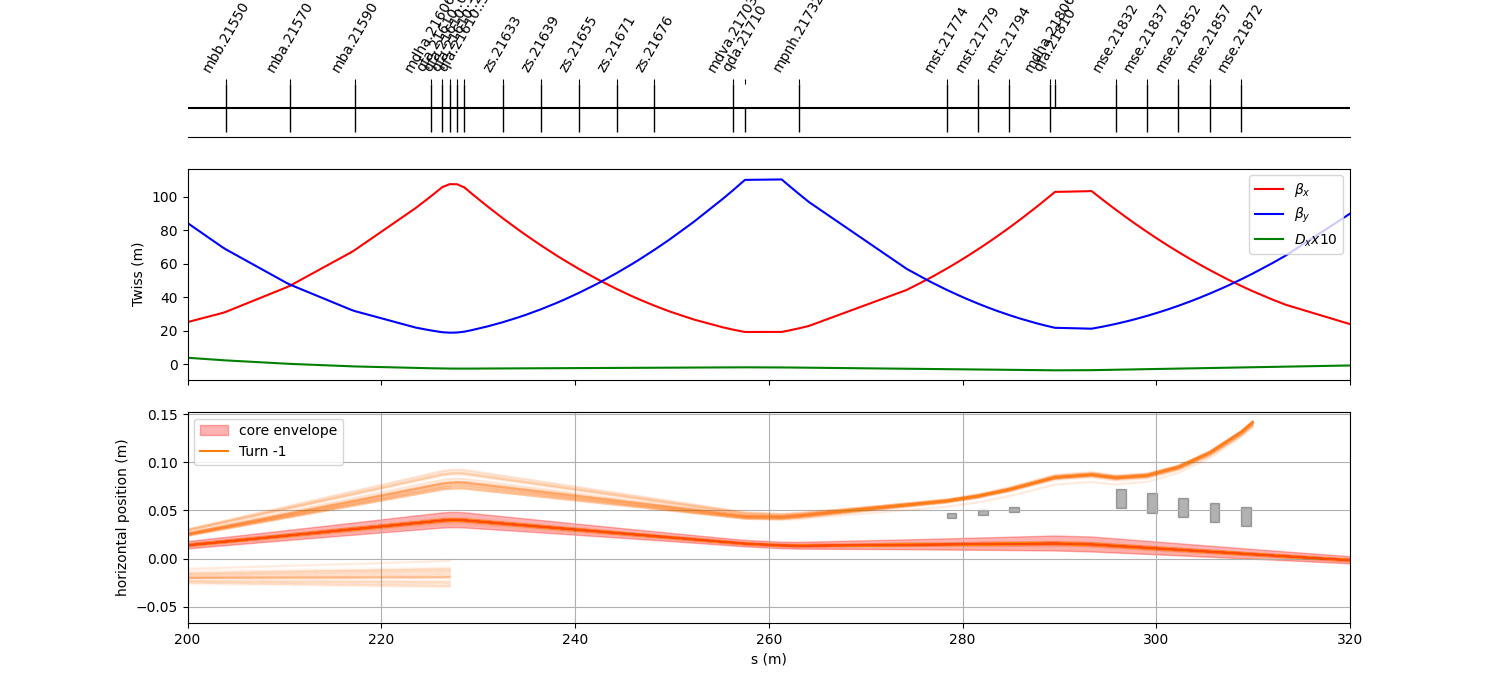

In [29]:
fig = plt.figure(figsize=(15,7))

plot_twiss(fig, tw_lss2, line)
fig.axes[2].grid(True)
fig.axes[2].set_xlim(200, 320)
fig.axes[2].set_xlabel('s (m)')
fig.axes[2].set_ylabel('horizontal position (m)')

# plotting of the envelope
fig.axes[2].plot(tw_lss2.s, tw_lss2.x, 'r-')
fig.axes[2].fill_between(tw_lss2.s, tw_lss2.x-sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), tw_lss2.x+sigma_x(tw_lss2.betx, tw_lss2.dx, n_sigma=5), color='r', alpha=0.3, label='core envelope')

for element_name in septa_names_with_apertures:
    x = line[element_name].interaction_process.blade_position
    thickness = line[element_name].interaction_process.thickness
    s = line.get_table()['s', element_name]
    fig.axes[2].add_patch(mpl.patches.Rectangle((s, x), 1, thickness, color='k', alpha=0.3))
    
   
   
## PLOTTING TRAJECTORIES   
n_traj = 500

ax = fig.axes[2]
alpha = 10/n_traj
plot_only_lost = False
num_turns = 1

all_trajs = tw_lss2_df.apply(lambda row: row['monitors'].x, axis=1)
all_trajs = np.stack(all_trajs.values)

for ipart in np.random.randint(0, particles._capacity, size=n_traj):
    state = particles.state[ipart]
    if plot_only_lost and state > 0:
        print(f"Skipping particle {ipart} ")
        continue

    particle_id = particles.particle_id[ipart]
    el_lost = particles.at_element[ipart]
    traj = all_trajs[:, particle_id, :]
    # print(f"Particle {ipart} lost at {el_lost} with state {state} and id {particle_id} ")

    if state <= 0:
        # need to recontruct the turns since the particle was last
        s_lost = line.get_table()['s', line.element_names[el_lost]]
        row_lost = tw_lss2_df[abs(tw_lss2_df['s'] - s_lost) < 30e-3].iloc[0]
        i_lost = row_lost['i_monitor']+1

        traj_corr = np.nan * np.ones_like(traj)
        traj_corr[:i_lost, -1] = traj[:i_lost, -1]
        for iturn in range(2, num_turns+1):
            traj_corr[:, -iturn] = np.hstack([traj[:i_lost, -iturn-1], traj[i_lost:, -iturn]])
        traj = traj_corr

    for iturn in range(1, num_turns+1):
        ax.plot(tw_lss2_df['s'], traj[:, -iturn], color=plt.cm.tab10(iturn), alpha=alpha, ls='-') 
for iturn in range(1, num_turns+1):
    ax.plot([], [], color=plt.cm.tab10(iturn), label=f"Turn -{iturn}")
ax.legend()

In [30]:
from collections import Counter

# Find lost particles
lost_particlesWithoutZS = particles.state <= 0

# Get the indices of lost particles
lost_indicesWithoutZS = np.where(lost_particlesWithoutZS)[0]

# Get the elements where particles are lost
lost_elementsWithoutZS = [line.element_names[particles.at_element[idx]] for idx in lost_indicesWithoutZS]

# Count the number of particles lost at each element
lost_countsWithoutZS = Counter(lost_elementsWithoutZS)

total_particlesLostZS = 0

# Print the counts
for element, count in lost_countsWithoutZS.items():
    print(f"Element {element}: {count} particles lost")
    total_particlesLostZS += count
print(f"Total number of lost particles: {total_particlesLostZS}")

# Count the number of particles lost at the element 'tt20.extraction'
ExtractedParticles = lost_countsWithoutZS.get('tt20.extraction', 0)

print(f"Number of particles extracted at tt20.extraction: {ExtractedParticles}")

print(f"")



Element tt20.extraction: 32 particles lost
Element extraction.crystal.dumper: 24 particles lost
Element extraction.crystal.2.: 1 particles lost
Total number of lost particles: 57
Number of particles extracted at tt20.extraction: 32



In [31]:
Efficiency = ExtractedParticles / total_particlesLostZS * 100
print(f"Efficiency: {Efficiency:.2f}%")

Efficiency: 56.14%


# Phase space analysis


Text(0, 0.5, "$x'$ (mrad)")

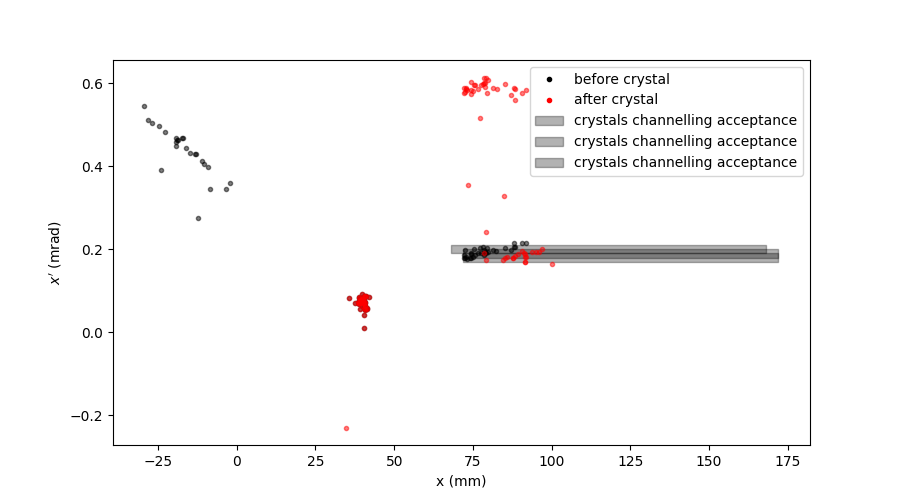

In [32]:
row_before_crystal = tw_lss2_df.loc['extraction.crystal.up.qfa21610']
row_after_crystal = tw_lss2_df.loc['extraction.crystal.dn.qfa21610']

fig, ax = plt.subplots(1, 1, figsize=(9,5))

ax.plot(row_before_crystal['monitors'].x[:,5]*1e3, row_before_crystal['monitors'].px[:,5] * 1e3, 'k.', alpha = 0.5)
ax.plot(row_after_crystal['monitors'].x[:,5] * 1e3, row_after_crystal['monitors'].px[:,5] * 1e3, 'r.', alpha = 0.5)
ax.plot()

ax.plot([], [], 'k.', label='before crystal')
ax.plot([], [], 'r.', label='after crystal')
ax.fill_between([crystal.jaw*1e3, crystal.jaw*1e3 + crystal.width*1e3], [crystal.tilt*1e3 - 10e-3]*2, [crystal.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
ax.fill_between([crystal2.jaw*1e3, crystal2.jaw*1e3 + crystal2.width*1e3], [crystal2.tilt*1e3 - 10e-3]*2, [crystal2.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
ax.fill_between([crystal2.jaw*1e3, crystal3.jaw*1e3 + crystal3.width*1e3], [crystal3.tilt*1e3 - 10e-3]*2, [crystal3.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')


ax.legend()

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")



In [33]:
tab = line.get_table()

# Inspecting other places in the sequence

## Phase space at the qdfa.21710

Text(0, 0.5, "$x'$ (mrad)")

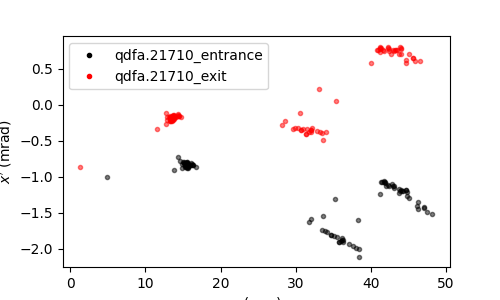

In [34]:
row_qdfa_entrance = tw_lss2_df.loc['qda.21710_entry']
row_qdfa_exit = tw_lss2_df.loc['qda.21710_exit']

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(row_qdfa_entrance['monitors'].x[:, 5] * 1e3, row_qdfa_entrance['monitors'].px[:, 5] * 1e3, 'k.', alpha=0.5)
ax.plot(row_qdfa_exit['monitors'].x[:, 5] * 1e3, row_qdfa_exit['monitors'].px[:, 5] * 1e3, 'r.', alpha=0.5)

ax.plot([], [], 'k.', label='qdfa.21710_entrance')
ax.plot([], [], 'r.', label='qdfa.21710_exit')

ax.legend()

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")

## Phase space at the crystal QDFA21710

In [35]:
"""
row_qda_entrance = tw_lss2_df.loc['extraction.crystal.up.qda21710']
row_qda_exit = tw_lss2_df.loc['extraction.crystal.dn.qda21710']

fig, ax = plt.subplots(1, 1, figsize=(5, 3))

ax.plot(row_qda_entrance['monitors'].x[:, 5] * 1e3, row_qda_entrance['monitors'].px[:, 5] * 1e3, 'k.', alpha=0.5)
ax.plot(row_qda_exit['monitors'].x[:, 5] * 1e3, row_qda_exit['monitors'].px[:, 5] * 1e3, 'r.', alpha=0.5)

ax.plot([], [], 'k.', label='qdfa.21710_entrance')
ax.plot([], [], 'r.', label='qdfa.21710_exit')

ax.legend()

ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")
""" 

'\nrow_qda_entrance = tw_lss2_df.loc[\'extraction.crystal.up.qda21710\']\nrow_qda_exit = tw_lss2_df.loc[\'extraction.crystal.dn.qda21710\']\n\nfig, ax = plt.subplots(1, 1, figsize=(5, 3))\n\nax.plot(row_qda_entrance[\'monitors\'].x[:, 5] * 1e3, row_qda_entrance[\'monitors\'].px[:, 5] * 1e3, \'k.\', alpha=0.5)\nax.plot(row_qda_exit[\'monitors\'].x[:, 5] * 1e3, row_qda_exit[\'monitors\'].px[:, 5] * 1e3, \'r.\', alpha=0.5)\n\nax.plot([], [], \'k.\', label=\'qdfa.21710_entrance\')\nax.plot([], [], \'r.\', label=\'qdfa.21710_exit\')\n\nax.legend()\n\nax.set_xlabel(\'x (mm)\')\nax.set_ylabel(r"$x\'$ (mrad)")\n'

## Phase space at ZS elements

Text(0, 0.5, "$x'$ (mrad)")

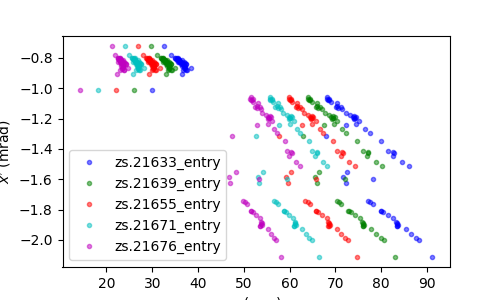

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

row_zs_21633_entry = tw_lss2_df.loc['zs.21633']
row_zs_21639_entry = tw_lss2_df.loc['zs.21639']
row_zs_21655_entry = tw_lss2_df.loc['zs.21655']
row_zs_21671_entry = tw_lss2_df.loc['zs.21671']
row_zs_21676_entry = tw_lss2_df.loc['zs.21676']

ax.plot(row_zs_21633_entry['monitors'].x[:, 5] * 1e3, row_zs_21633_entry['monitors'].px[:, 5] * 1e3, '.', color='b', alpha=0.5, label='zs.21633_entry')
ax.plot(row_zs_21639_entry['monitors'].x[:, 5] * 1e3, row_zs_21639_entry['monitors'].px[:, 5] * 1e3, '.', color='g', alpha=0.5, label='zs.21639_entry')
ax.plot(row_zs_21655_entry['monitors'].x[:, 5] * 1e3, row_zs_21655_entry['monitors'].px[:, 5] * 1e3, '.', color='r', alpha=0.5, label='zs.21655_entry')
ax.plot(row_zs_21671_entry['monitors'].x[:, 5] * 1e3, row_zs_21671_entry['monitors'].px[:, 5] * 1e3, '.', color='c', alpha=0.5, label='zs.21671_entry')
ax.plot(row_zs_21676_entry['monitors'].x[:, 5] * 1e3, row_zs_21676_entry['monitors'].px[:, 5] * 1e3, '.', color='m', alpha=0.5, label='zs.21676_entry')

ax.legend()
ax.set_xlabel('x (mm)')
ax.set_ylabel(r"$x'$ (mrad)")